In [9]:
import pandas as pd

import numpy as np

In [7]:
data = pd.read_csv('data/card_transdata.csv')
data.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


**EDA**

Now that the data is loaded, we can begin EDA

In [4]:
print("shape:",data.shape) #large dataset: 1,000,000 rows
data.info()
data.value_counts()

shape: (1000000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


distance_from_home  distance_from_last_transaction  ratio_to_median_purchase_price  repeat_retailer  used_chip  used_pin_number  online_order  fraud
0.004874            0.198102                        0.998148                        0.0              0.0        0.0              1.0           0.0      1
18.271839           0.558001                        0.161158                        1.0              0.0        0.0              1.0           0.0      1
18.271944           0.079844                        0.264669                        1.0              0.0        0.0              0.0           0.0      1
18.271993           1.078692                        0.712373                        1.0              0.0        0.0              1.0           0.0      1
18.272016           0.197228                        0.615863                        1.0              0.0        0.0              0.0           0.0      1
                                                                                 

In [28]:
print(data.columns)

Index(['distance_from_home', 'distance_from_last_transaction',
       'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip',
       'used_pin_number', 'online_order', 'fraud'],
      dtype='object')


In [4]:
#check for missing values
print(data.isna().values.any())
print(data.isnull().values.any())

False
False


This dataset contains no missing values.

Now, let's plot the target variable, which is 'fraud'. 'Fraud' is a categorical variable where an output of 0 means that the transaction was not fraudulent and an output of 1 means that it was. Let's find out what percentage of all transactions in this data
set were fraudulent.

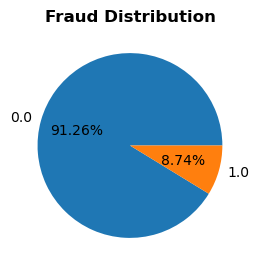

In [39]:
#TARGET VARIABLE
#bar plot
#data['fraud'].value_counts().plot(kind='bar')

#pie plot

import matplotlib
import matplotlib.pyplot as plt


#pie chart
plt.figure(figsize = (5, 3))
plt.pie(x = data['fraud'].value_counts().values,
        labels = data['fraud'].value_counts().index, 
        autopct = '%1.2f%%')
plt.title('Fraud Distribution', size = 12, weight = 'bold')
# caption = "8.74% of transactions in the dataset belong to class 1 and are fraudulent."
# plt.figtext(0.55, 0.05, caption, wrap=True, horizontalalignment='center', fontsize=10)
plt.savefig('target_eda.png', dpi=300)
plt.show()
#only 8.74% of all transactions are fraudulent


We can see that 8.74% of all transactions in our dataset were fraudulent.


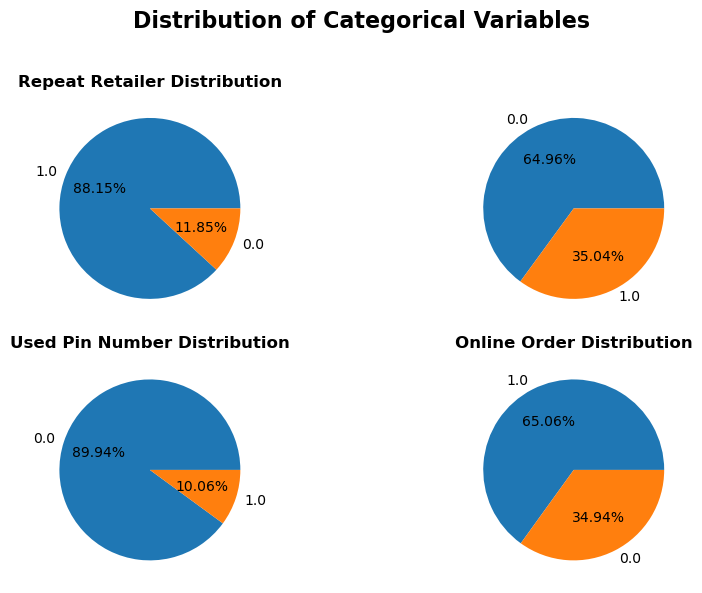

In [8]:
#Non-target categorical variables

# plt.figure(figsize = (5, 3))
# plt.pie(x = data['repeat_retailer'].value_counts().values,
#         labels = data['repeat_retailer'].value_counts().index, 
#         autopct = '%1.2f%%')
# plt.title('Repeat Retailer Distribution', size = 12, weight = 'bold')
# caption = "Percentage of transactions in which the customer was a repeat retailer (1) versus not (0)"
# plt.figtext(0.5, 0, caption, wrap=True, horizontalalignment='center', fontsize=10)
# plt.show()

# plt.figure(figsize = (5, 3))
# plt.pie(x = data['used_chip'].value_counts().values,
#         labels = data['used_chip'].value_counts().index, 
#         autopct = '%1.2f%%')
# plt.title('Used Chip Distribution', size = 12, weight = 'bold')
# caption = "Percentage of transactions in which a chip was used (1) versus not (0)"
# plt.figtext(0.5, 0, caption, wrap=True, horizontalalignment='center', fontsize=10)
# plt.show()


# plt.figure(figsize = (5, 3))
# plt.pie(x = data['used_pin_number'].value_counts().values,
#         labels = data['used_pin_number'].value_counts().index, 
#         autopct = '%1.2f%%')
# plt.title('Used Pin Number Distribution', size = 12, weight = 'bold')
# caption = "Percentage of transactions in which a pin number was used (1) versus not (0)"
# plt.figtext(0.5, 0, caption, wrap=True, horizontalalignment='center', fontsize=10)
# plt.show()

# plt.figure(figsize = (5, 3))
# plt.pie(x = data['online_order'].value_counts().values,
#         labels = data['online_order'].value_counts().index, 
#         autopct = '%1.2f%%')
# caption = "Percentage of transactions that were online orders (1) versus not (0)"
# plt.title('Online Order Distribution', size = 12, weight = 'bold')
# plt.figtext(0.5, 0, caption, wrap=True, horizontalalignment='center', fontsize=10)
# plt.show()

import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle('Distribution of Categorical Variables', size=16, weight='bold')

# Plot for Repeat Retailer Distribution
axs[0, 0].pie(x=data['repeat_retailer'].value_counts().values,
              labels=data['repeat_retailer'].value_counts().index,
              autopct='%1.2f%%')
axs[0, 0].set_title('Repeat Retailer Distribution', size=12, weight='bold')
# caption = "Percentage of transactions in which the customer was a repeat retailer (1) versus not (0)"
# axs[0, 0].text(0.1, -1.3, caption, wrap=True, horizontalalignment='center', fontsize=10)

# Plot for Used Chip Distribution
axs[0, 1].pie(x=data['used_chip'].value_counts().values,
              labels=data['used_chip'].value_counts().index,
              autopct='%1.2f%%')
# axs[0, 1].set_title('Used Chip Distribution', size=12, weight='bold')
# caption = "Percentage of transactions in which a chip was used (1) versus not (0)"
# axs[0, 1].text(1.1, -1.4, caption, wrap=True, horizontalalignment='center', fontsize=10)

# Plot for Used Pin Number Distribution
axs[1, 0].pie(x=data['used_pin_number'].value_counts().values,
              labels=data['used_pin_number'].value_counts().index,
              autopct='%1.2f%%')
axs[1, 0].set_title('Used Pin Number Distribution', size=12, weight='bold')
# caption = "Percentage of transactions in which a pin number was used (1) versus not (0)"
# axs[1, 0].text(0.1, -1.4, caption, wrap=True, horizontalalignment='center', fontsize=10)

# Plot for Online Order Distribution
axs[1, 1].pie(x=data['online_order'].value_counts().values,
              labels=data['online_order'].value_counts().index,
              autopct='%1.2f%%')
axs[1, 1].set_title('Online Order Distribution', size=12, weight='bold')
# caption = "Percentage of transactions that were online orders (1) versus not (0)"
# axs[1, 1].text(0.9, -1.5, caption, wrap=True, horizontalalignment='center', fontsize=10)
plt.savefig('dist_cat.png', dpi=300)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


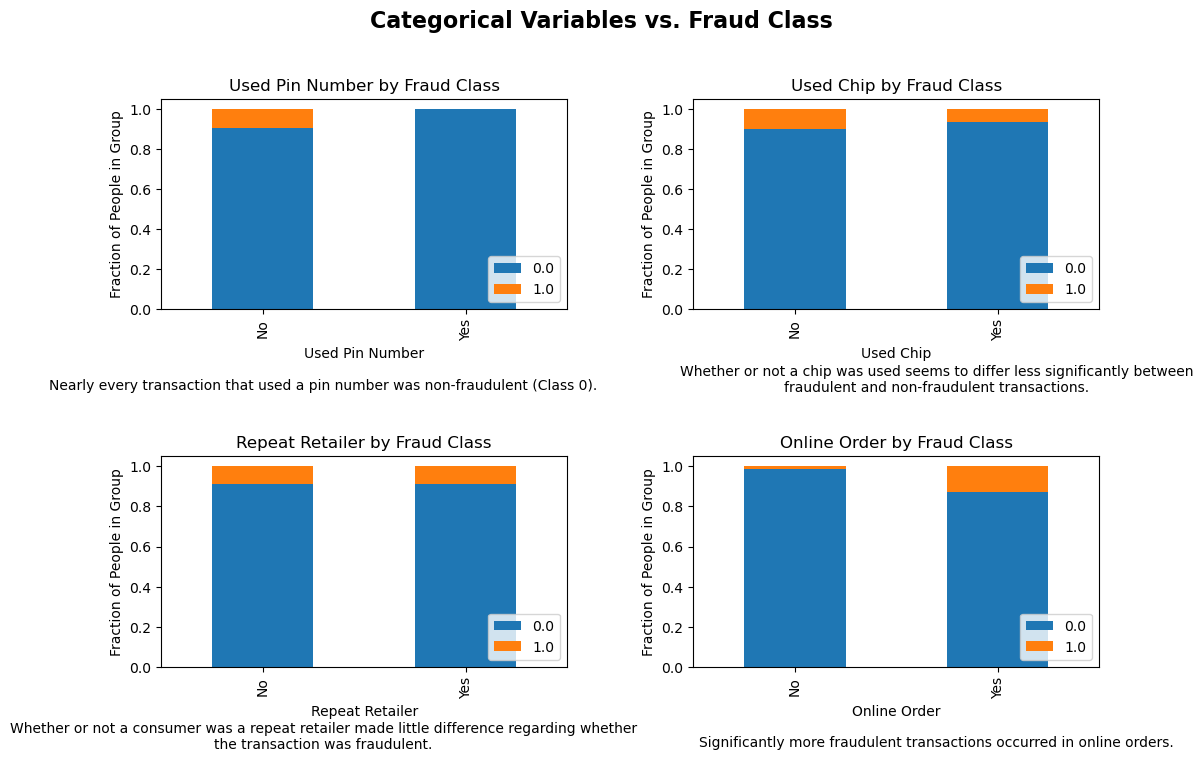

In [9]:
# #CATEGORICAL VERSUS TARGET


import matplotlib.pyplot as plt
import pandas as pd

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Categorical Variables vs. Fraud Class', size=16, weight='bold')

# Plot for Used Pin Number
count_matrix = data.groupby(['used_pin_number', 'fraud']).size().unstack()
count_matrix_norm = count_matrix.div(count_matrix.sum(axis=1), axis=0)
axs[0, 0] = count_matrix_norm.plot(kind='bar', stacked=True, ax=axs[0, 0])
axs[0, 0].set_xticklabels(['No', 'Yes'])
axs[0, 0].set_xlabel('Used Pin Number')
axs[0, 0].set_ylabel('Fraction of People in Group')
axs[0, 0].legend(loc=4)
axs[0, 0].set_title('Used Pin Number by Fraud Class')
caption = "Nearly every transaction that used a pin number was non-fraudulent (Class 0)."
axs[0, 0].text(0.3, -0.4, caption, wrap=True, horizontalalignment='center', fontsize=10)

# Plot for Used Chip
count_matrix = data.groupby(['used_chip', 'fraud']).size().unstack()
count_matrix_norm = count_matrix.div(count_matrix.sum(axis=1), axis=0)
axs[0, 1] = count_matrix_norm.plot(kind='bar', stacked=True, ax=axs[0, 1])
axs[0, 1].set_xticklabels(['No', 'Yes'])
axs[0, 1].set_xlabel('Used Chip')
axs[0, 1].set_ylabel('Fraction of People in Group')
axs[0, 1].legend(loc=4)
axs[0, 1].set_title('Used Chip by Fraud Class')
caption = "Whether or not a chip was used seems to differ less significantly between fraudulent and non-fraudulent transactions."
axs[0, 1].text(0.7, -0.4, caption, wrap=True, horizontalalignment='center', fontsize=10)

# Plot for Repeat Retailer
count_matrix = data.groupby(['repeat_retailer', 'fraud']).size().unstack()
count_matrix_norm = count_matrix.div(count_matrix.sum(axis=1), axis=0)
axs[1, 0] = count_matrix_norm.plot(kind='bar', stacked=True, ax=axs[1, 0])
axs[1, 0].set_xticklabels(['No', 'Yes'])
axs[1, 0].set_xlabel('Repeat Retailer')
axs[1, 0].set_ylabel('Fraction of People in Group')
axs[1, 0].legend(loc=4)
axs[1, 0].set_title('Repeat Retailer by Fraud Class')
caption = "Whether or not a consumer was a repeat retailer made little difference regarding whether the transaction was fraudulent."
axs[1, 0].text(0.3, -0.4, caption, wrap=True, horizontalalignment='center', fontsize=10)

# Plot for Online Order
count_matrix = data.groupby(['online_order', 'fraud']).size().unstack()
count_matrix_norm = count_matrix.div(count_matrix.sum(axis=1), axis=0)
axs[1, 1] = count_matrix_norm.plot(kind='bar', stacked=True, ax=axs[1, 1])
axs[1, 1].set_xticklabels(['No', 'Yes'])
axs[1, 1].set_xlabel('Online Order')
axs[1, 1].set_ylabel('Fraction of People in Group')
axs[1, 1].legend(loc=4)
axs[1, 1].set_title('Online Order by Fraud Class')
caption = "Significantly more fraudulent transactions occurred in online orders."
axs[1, 1].text(0.7, -0.4, caption, wrap=True, horizontalalignment='center', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('cat_target.png', dpi=300)
plt.show()


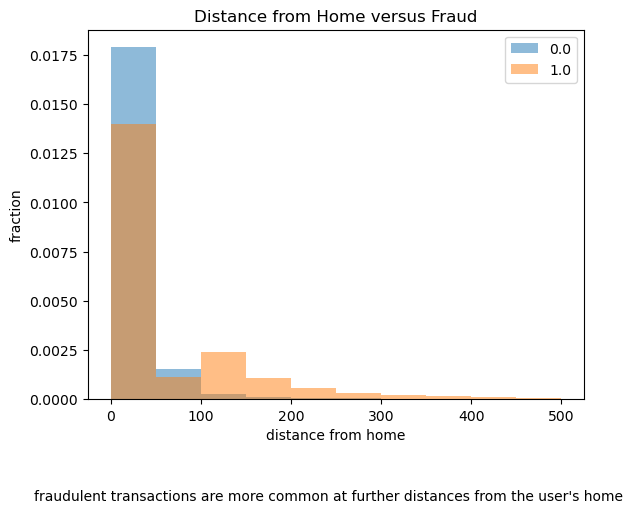

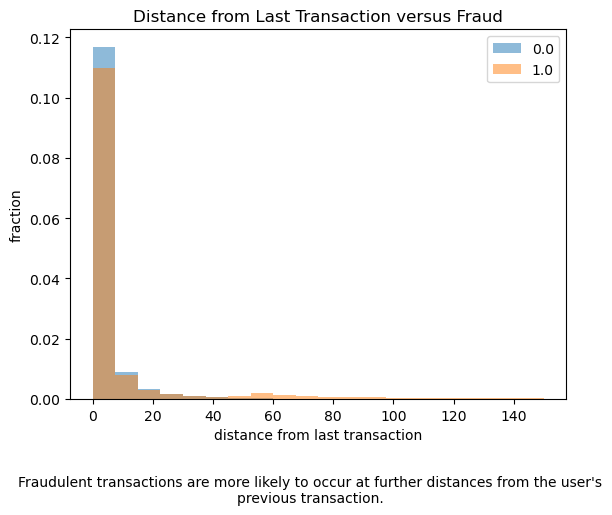

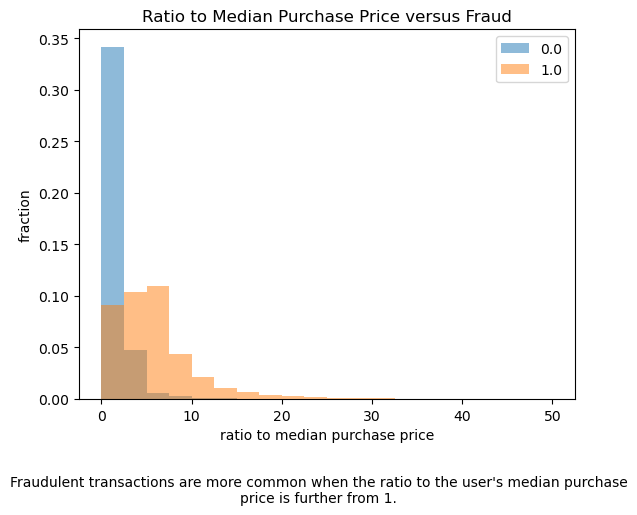

In [19]:
#histogram
#continuous to categorical: distance_from_home
categories = data['fraud'].unique()
bin_range = (data['distance_from_home'].min(), 500
            )


for c in categories:
    plt.hist(data[data['fraud']==c]['distance_from_home'],alpha=0.5,label=c,range=bin_range,bins=10,density=True)
plt.legend()
plt.ylabel('fraction')
plt.xlabel('distance from home')
plt.title('Distance from Home versus Fraud')
caption = ("Fraudulent transactions are more common at further distances from the user's home.")
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=10)
plt.savefig('distancefromhome.png', dpi=300)
plt.show()

categories2 = data['fraud'].unique()
bin_range2 = (data['distance_from_home'].min(), 150
              
            )


for c in categories2:
    plt.hist(data[data['fraud']==c]['distance_from_last_transaction'],alpha=0.5,label=c,range=bin_range2,bins=20,density=True)
plt.legend()
plt.ylabel('fraction')
plt.xlabel('distance from last transaction')
plt.title('Distance from Last Transaction versus Fraud')
caption =("Fraudulent transactions are more likely to occur at further distances from the user's previous transaction.")
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=10)
plt.savefig('distlasttransaction.png', dpi=300)
plt.show()


#RATIO
categories3= data['fraud'].unique()
bin_range2 = (data['ratio_to_median_purchase_price'].min(), 50
            )

for c in categories3:
    plt.hist(data[data['fraud']==c]['ratio_to_median_purchase_price'],alpha=0.5,label=c,range=bin_range2,bins=20,density=True)
plt.legend()
plt.ylabel('fraction')
plt.xlabel('ratio to median purchase price')
plt.title('Ratio to Median Purchase Price versus Fraud')
caption = ("Fraudulent transactions are more common when the ratio to the user's median purchase price is further from 1.")
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=10)
plt.savefig('ratio_purchase_price.png', dpi=300)
plt.show()


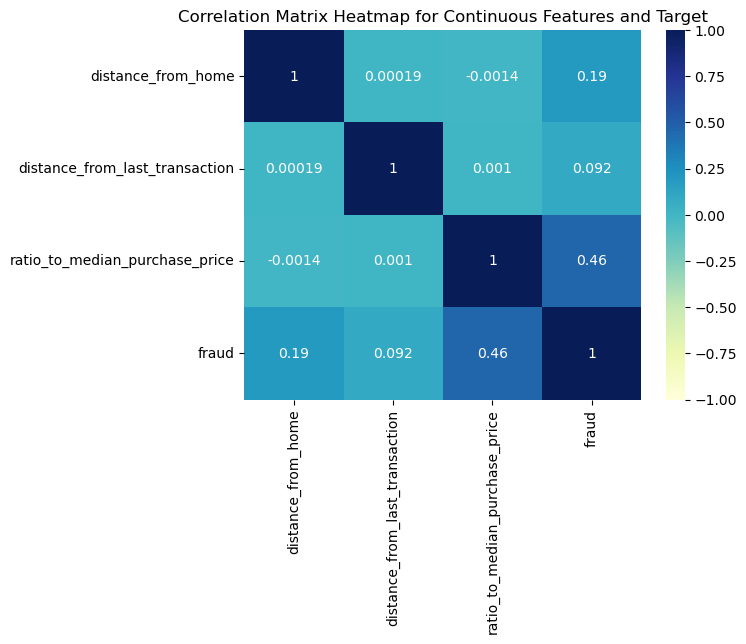

In [26]:
#check for correlated features
X = data.drop(['used_chip', 'used_pin_number', 'online_order', 'repeat_retailer'], axis=1)

y=data['fraud']

import seaborn as sns
corr_matrix = X.corr(method='pearson', min_periods=1, numeric_only=False) 

sns.heatmap(corr_matrix, vmin=-1, vmax=1, annot=True, cmap="YlGnBu")
plt.title('Correlation Matrix Heatmap for Continuous Features and Target')
plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


We can see that none of the features are closely correlated, meaning we do not need to get rid of features to improve the convergence time of the model.

**Split Data**

Since this is a large dataset, 98% of data will be in the training set, 1% in the validation set, and 1% in the test set. The data is unbalanced, so I will be using the 'stratify' argument in train_test_split.


In [10]:
print(y.value_counts())

fraud
0.0    912597
1.0     87403
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split
#identify feature matrix and target feature
X=data.loc[:,data.columns != 'fraud']
y=data['fraud']

#stratified train_test_split
random_state = 42

X_train, X_other, y_train, y_other = train_test_split(X,y,train_size = 0.98,stratify=y,random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_other,y_other,train_size = 0.5,stratify=y_other,random_state=random_state)
print('**balance with stratification:**')
print(np.unique(y_train,return_counts=True))
print(np.unique(y_val,return_counts=True))
print(np.unique(y_test,return_counts=True))

print('validation set:',X_val.shape, y_val.shape) # 1% of points are in validation
print('test set:',X_test.shape, y_test.shape) # 1% of points are in test
print('train set:', X_train.shape, y_train.shape) #98% of points are in train
print(X_train.head())



**balance with stratification:**
(array([0., 1.]), array([894345,  85655]))
(array([0., 1.]), array([9126,  874]))
(array([0., 1.]), array([9126,  874]))
validation set: (10000, 7) (10000,)
test set: (10000, 7) (10000,)
train set: (980000, 7) (980000,)
        distance_from_home  distance_from_last_transaction  \
773522            7.437069                        2.516719   
756690           14.028811                        0.493430   
801928          120.716495                        0.021280   
801345            1.683694                        0.346633   
283515           14.249239                        0.591916   

        ratio_to_median_purchase_price  repeat_retailer  used_chip  \
773522                        0.608334              1.0        1.0   
756690                        0.719204              1.0        0.0   
801928                        0.966234              1.0        0.0   
801345                        2.435943              0.0        1.0   
283515                  

**Preprocessing**

Categorical features: repeat_retailer, used_chip, used_pin_number, online_order
Continuous features: distance_from_home, distance_from_last_transaction, ratio_to_median_purchase_price

The continuous features all follow a tail distribution so I will preprocess them using StandardScaler.
I'll use OneHotEncoder to preprocess the categorical variables. Even though they don't necessarily need to be preprocessed since they are already zeroes and ones and there are no missing values, I will run OneHotEncoder so I don't have to re-append the columns to my preprocoessed data.


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


cat_ftrs = ['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']
std_ftrs = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']

preprocessor = ColumnTransformer(
   transformers=[
        ('onehot', OneHotEncoder(sparse_output=False, handle_unknown= 'ignore'), cat_ftrs),
        ('std', StandardScaler(), std_ftrs)])


clf = Pipeline(steps=[('preprocessor', preprocessor)])

X_train_prep = clf.fit_transform(X_train)
X_val_prep = clf.fit_transform(X_val)
X_test_prep = clf.fit_transform(X_test)

print("X train shape", X_train.shape)
print("X train prep shape", X_train_prep.shape)
print("X train prep:", X_train_prep)


#initialize the encoder
enc = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
# fit encoder
enc.fit(X_train[cat_ftrs])
# transform X_train
onehot_train = enc.transform(X_train[cat_ftrs])
print('transformed train features:')
print(onehot_train)
# transform X_val
onehot_val = enc.transform(X_val[cat_ftrs])
print('transformed val features:')
print(onehot_val) 
# transform X_test
onehot_test = enc.transform(X_test[cat_ftrs])
print('transformed test features:')
print(onehot_test)


X train shape (980000, 7)
X train prep shape (980000, 11)
X train prep: [[ 0.          1.          0.         ... -0.29324088 -0.09715076
  -0.43414526]
 [ 0.          1.          1.         ... -0.19258739 -0.1751522
  -0.39457111]
 [ 0.          1.          1.         ...  1.43649443 -0.19335442
  -0.30639616]
 ...
 [ 0.          1.          0.         ... -0.33764006  1.57622055
   0.00236275]
 [ 0.          1.          1.         ... -0.11499707 -0.1772184
  -0.59175009]
 [ 0.          1.          1.         ... -0.35901419  0.14317666
  -0.48900832]]
transformed train features:
[[0. 1. 0. ... 0. 0. 1.]
 [0. 1. 1. ... 0. 0. 1.]
 [0. 1. 1. ... 0. 1. 0.]
 ...
 [0. 1. 0. ... 0. 0. 1.]
 [0. 1. 1. ... 1. 1. 0.]
 [0. 1. 1. ... 0. 0. 1.]]
transformed val features:
[[0. 1. 1. ... 0. 1. 0.]
 [1. 0. 1. ... 0. 1. 0.]
 [0. 1. 1. ... 0. 0. 1.]
 ...
 [0. 1. 0. ... 0. 0. 1.]
 [1. 0. 1. ... 0. 1. 0.]
 [1. 0. 0. ... 0. 0. 1.]]
transformed test features:
[[0. 1. 0. ... 1. 0. 1.]
 [1. 0. 1. ... 0. 1.

In [19]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import GridSearchCV, KFold, train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.metrics import make_scorer
from sklearn.linear_model import LogisticRegression, ElasticNet, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
# function for the ML pipeline as outlined above 

data = pd.read_csv('data/card_transdata.csv')
#feature matrix and target variable


# X=data.loc[:,data.columns != 'fraud']
# y=data['fraud']

subset_size = 15000
subset_df = data.sample(n=subset_size, random_state=42, replace=False) 

X=subset_df.loc[:,subset_df.columns != 'fraud']
y=subset_df['fraud']



#set preprocessor

cat_ftrs = ['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']
std_ftrs = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']

preprocessor = ColumnTransformer(
   transformers=[
        ('onehot', OneHotEncoder(sparse_output=False, handle_unknown= 'ignore'), cat_ftrs),
        ('std', StandardScaler(), std_ftrs)])

#parameter grid
param_grids = {
    'Logistic': {'logisticregression__C': np.logspace(-3, 3, 7)},
    'RandomForest': {'randomforestclassifier__n_estimators': [10, 50, 100],
                     'randomforestclassifier__max_depth': [10, 20]},
    'SVC': {'svc__C': np.logspace(-3, 3, 7),
            'svc__gamma': ['scale', 'auto']},
    'KNN': {'kneighborsclassifier__n_neighbors': [1, 3, 5, 10]
           }
}

#models
rf_model = RandomForestClassifier(random_state=42)
svc_model = SVC()
knn_model = KNeighborsClassifier()
log_model = LogisticRegression(random_state=42)

             
#pipeline
def MLpipe_KFold_accuracy(X, y, preprocessor, ML_algo, param_grid):
    test_scores = []
    best_models = []
    for random_state in range(10):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=random_state) 
        kf = StratifiedKFold(n_splits=3,shuffle=True,random_state=random_state)
        print(X_train.shape)
        pipe = make_pipeline(preprocessor, ML_algo)
        # Set up the parameter grid           
        grid = GridSearchCV(pipe, param_grid=param_grid,scoring = make_scorer(mean_squared_error, greater_is_better=False, squared=False), cv=kf,
                           return_train_score = True, n_jobs=-1, verbose=True) 
        # Fit the model using GridSearchCV
        grid.fit(X_train, y_train)
        best_models.append(grid)
        accuracy = accuracy_score(y_test, grid.predict(X_test))

        # Append the test score and best model to the lists
        test_scores.append(accuracy)
    return test_scores, best_models


#save models
log_test_scores, log_best_models = MLpipe_KFold_accuracy(X, y, preprocessor, log_reg, param_grids["Logistic"])
rf_test_scores, rf_best_models = MLpipe_KFold_accuracy(X, y, preprocessor, rf_model, param_grids["RandomForest"])
svc_test_scores, svc_best_models = MLpipe_KFold_accuracy(X, y, preprocessor, svc_model, param_grids["SVC"])
knn_test_scores, knn_best_models = MLpipe_KFold_accuracy(X, y, preprocessor, knn_model, param_grids["KNN"])



print(f"Random Forest Standard Deviation of Test Accuracy, {np.std(rf_test_scores)}")
print(f"Random Forest Mean Test Accuracy, {np.mean(rf_test_scores)}")

print(f"Logistic Standard Deviation of Test Accuracy, {np.std(log_test_scores)}")
print(f"Logistic Mean Test Accuracy, {np.mean(log_test_scores)}")

print(f"SVC Standard Deviation of Test Accuracy, {np.std(svc_test_scores)}")
print(f"SVC Mean Test Accuracy, {np.mean(svc_test_scores)}")

print(f"KNN Standard Deviation of Test Accuracy, {np.std(knn_test_scores)}")
print(f"KNN Mean Test Accuracy, {np.mean(knn_test_scores)}")




(12000, 7)
Fitting 3 folds for each of 7 candidates, totalling 21 fits
(12000, 7)
Fitting 3 folds for each of 7 candidates, totalling 21 fits
(12000, 7)
Fitting 3 folds for each of 7 candidates, totalling 21 fits
(12000, 7)
Fitting 3 folds for each of 7 candidates, totalling 21 fits
(12000, 7)
Fitting 3 folds for each of 7 candidates, totalling 21 fits
(12000, 7)
Fitting 3 folds for each of 7 candidates, totalling 21 fits
(12000, 7)
Fitting 3 folds for each of 7 candidates, totalling 21 fits
(12000, 7)
Fitting 3 folds for each of 7 candidates, totalling 21 fits
(12000, 7)
Fitting 3 folds for each of 7 candidates, totalling 21 fits
(12000, 7)
Fitting 3 folds for each of 7 candidates, totalling 21 fits
(12000, 7)
Fitting 3 folds for each of 6 candidates, totalling 18 fits
(12000, 7)
Fitting 3 folds for each of 6 candidates, totalling 18 fits
(12000, 7)
Fitting 3 folds for each of 6 candidates, totalling 18 fits
(12000, 7)
Fitting 3 folds for each of 6 candidates, totalling 18 fits
(12000

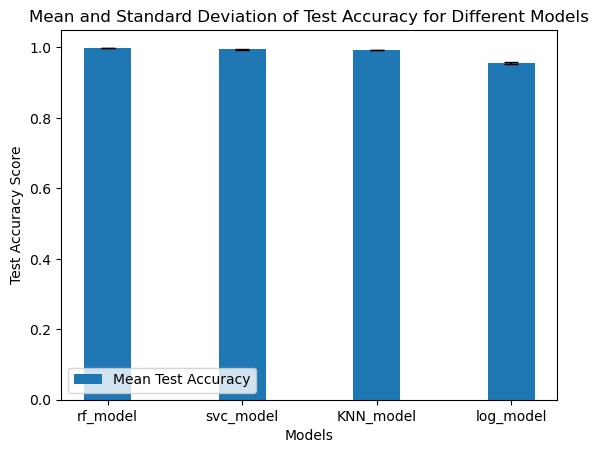

In [22]:
import matplotlib.pyplot as plt

models = ['rf_model', 'svc_model', 'KNN_model', 'log_model']
mean_scores = [np.mean(rf_test_scores),
               np.mean(svc_test_scores),
               np.mean(knn_test_scores),
               np.mean(log_test_scores)]
std_devs = [np.std(rf_test_scores),
            np.std(svc_test_scores),
            np.std(knn_test_scores),
            np.std(log_test_scores)]

# Plotting
fig, ax = plt.subplots()
bar_width = 0.35
index = np.arange(len(models))

bar1 = ax.bar(index, mean_scores, bar_width, label='Mean Test Accuracy', yerr=std_devs, capsize=5)

ax.set_xlabel('Models')
ax.set_ylabel('Test Accuracy Score')
ax.set_title('Mean and Standard Deviation of Test Accuracy for Different Models')
ax.set_xticks(index)
ax.set_xticklabels(models)
ax.legend()
plt.savefig('mean_std1.png', dpi=300)
plt.show()

In [1]:
#IMPORT
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import GridSearchCV, KFold, train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import make_scorer
from sklearn.linear_model import LogisticRegression, Lasso, Ridge, ElasticNet
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

Because this dataset is simulated, we see an extremely high accuracyfor each of these models.We see that Random Forest has the lhighest accuracy score.

Fitting 3 folds for each of 6 candidates, totalling 18 fits
        Actual  Predicted
263245     0.0        0.0
961975     0.0        0.0
275346     0.0        0.0
998436     1.0        1.0
489168     1.0        1.0
...        ...        ...
482053     0.0        0.0
899599     0.0        0.0
131979     0.0        0.0
728199     0.0        0.0
391133     0.0        0.0

[3000 rows x 2 columns]


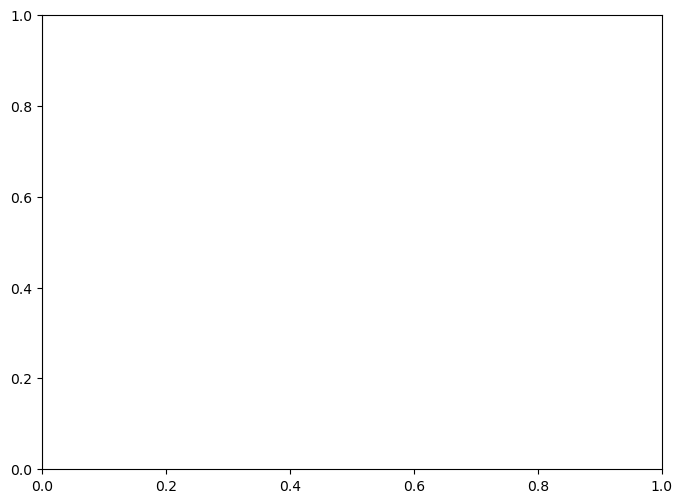

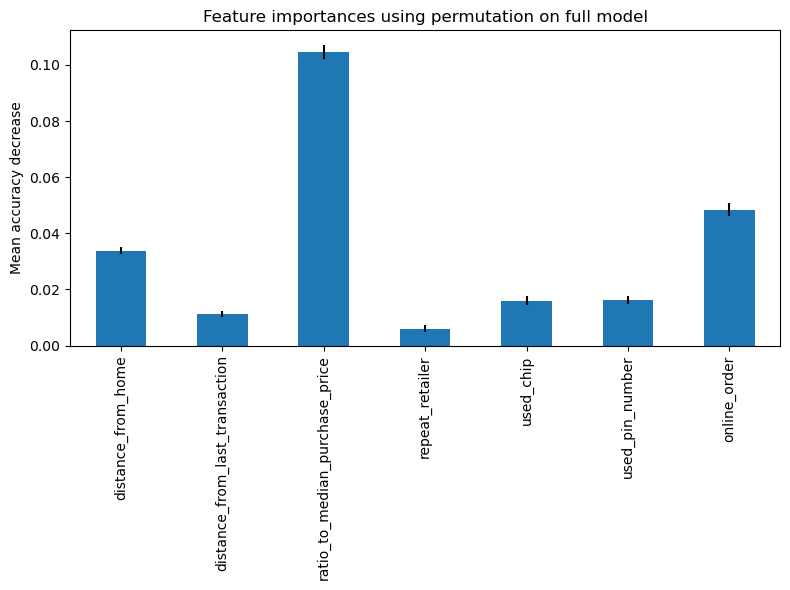

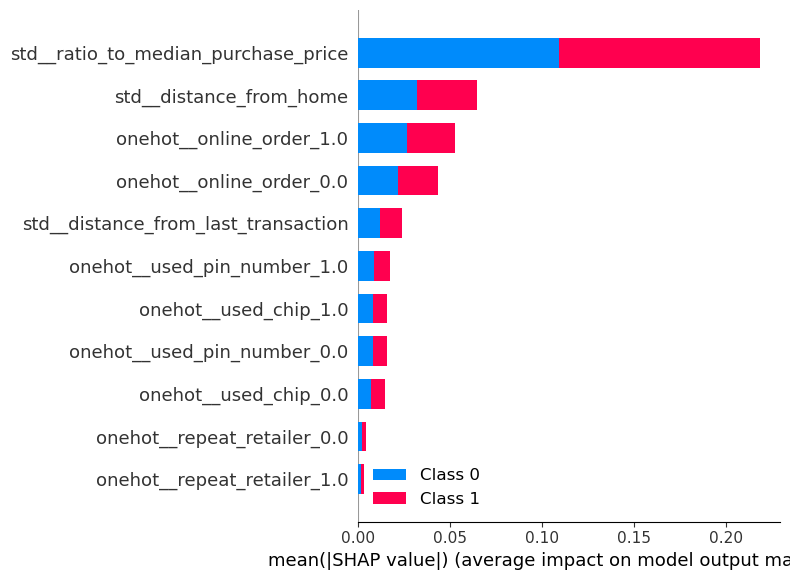

<Figure size 640x480 with 0 Axes>

Shape of shap_values[0]: (3000, 11)
Shape of X_test_transformed: (3000, 11)
Length of feature_names1: 11


No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


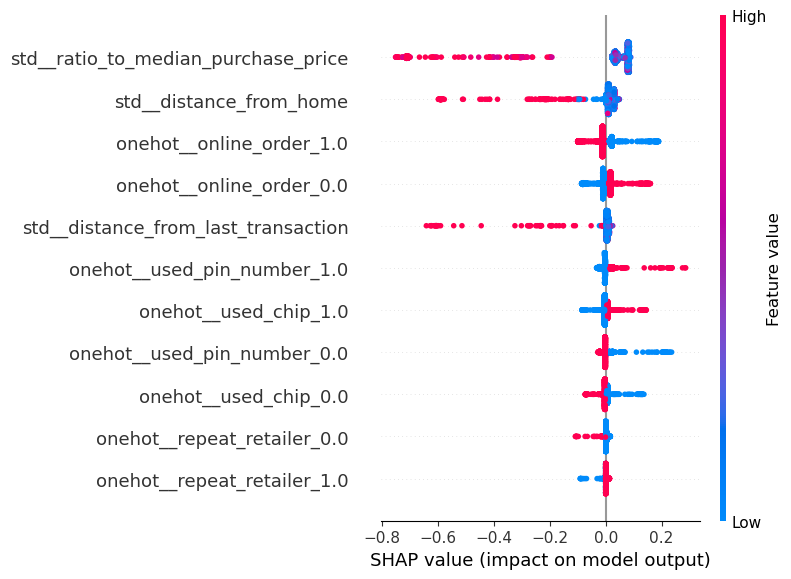

<Figure size 640x480 with 0 Axes>

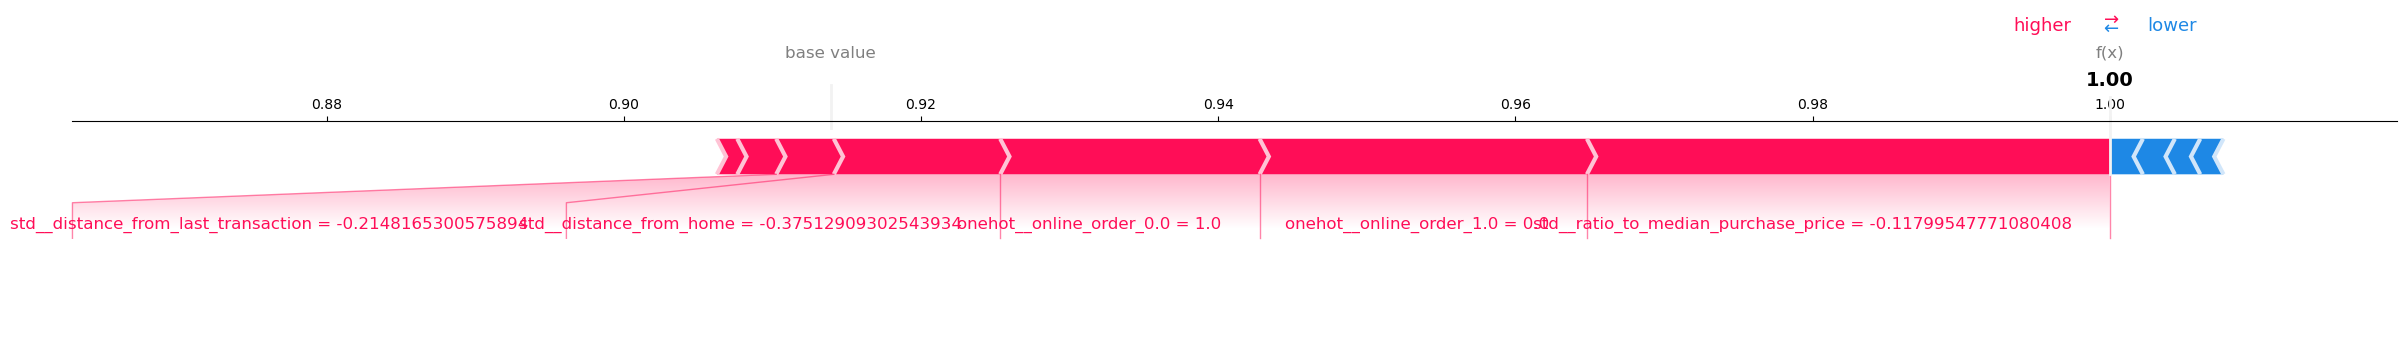

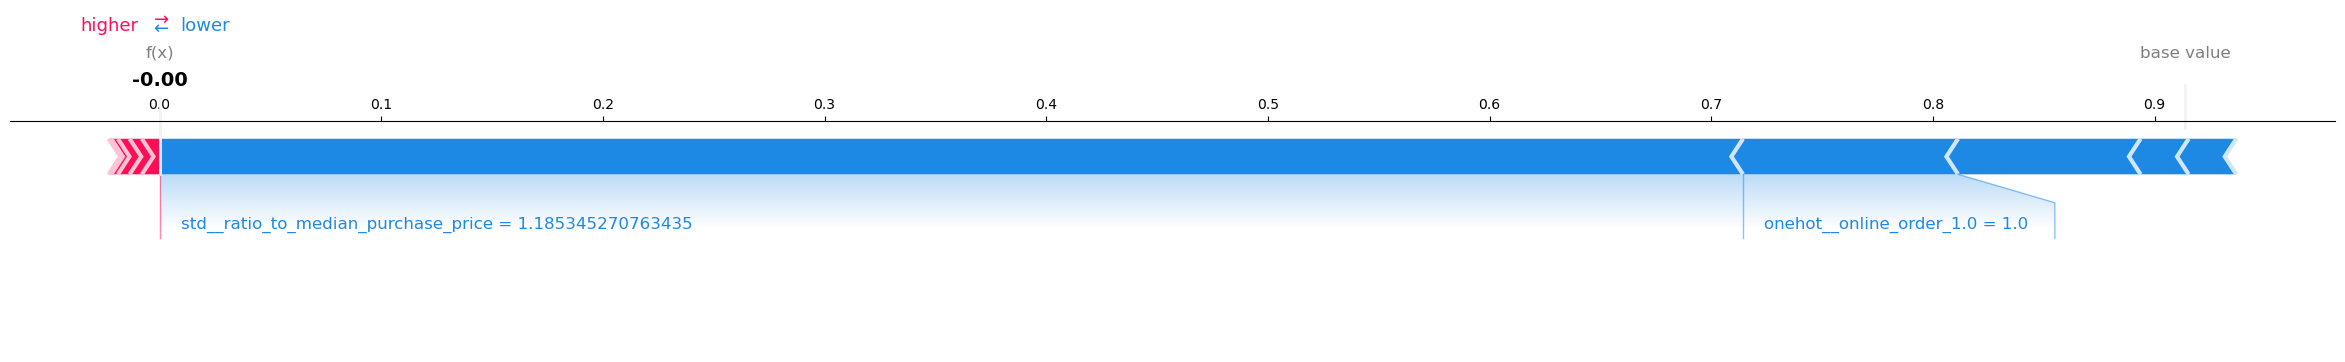

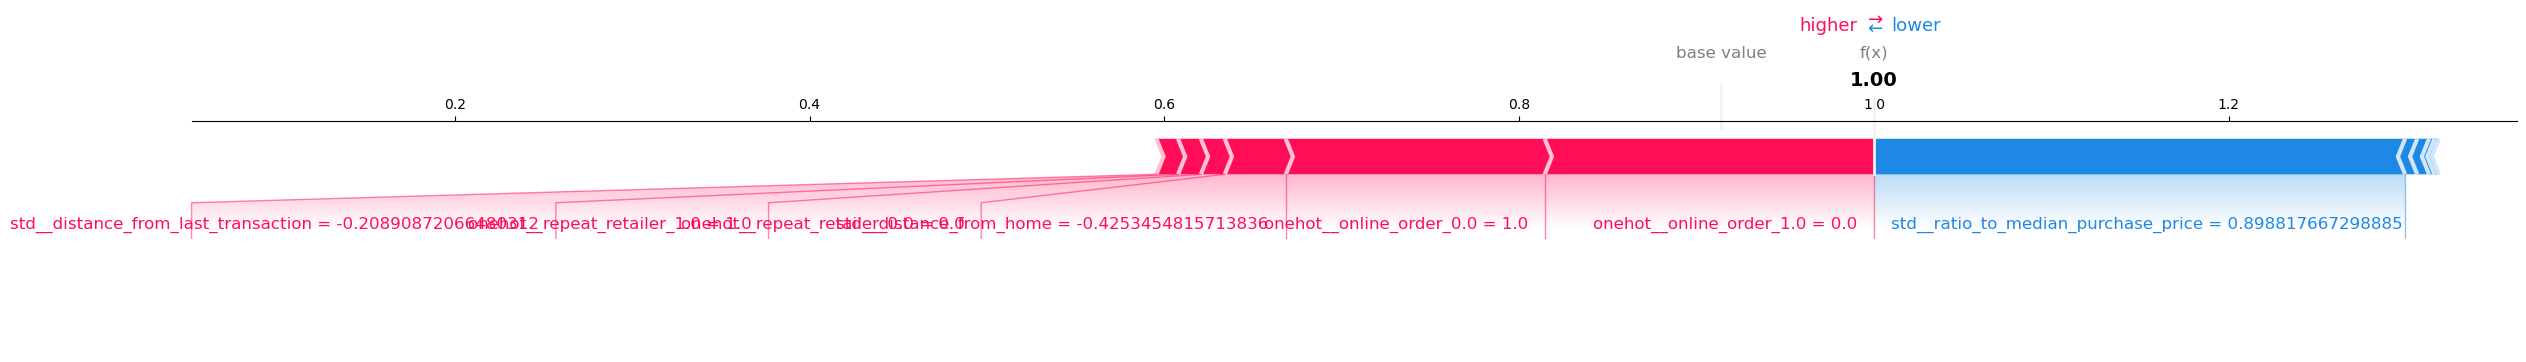

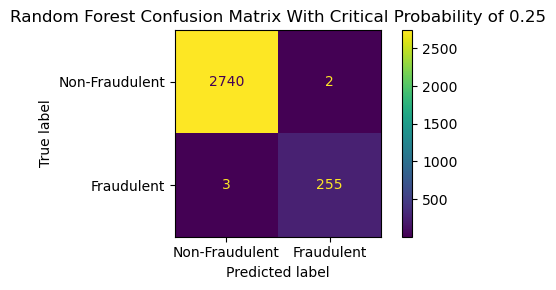

Accuracy: 0.9981666666666668
Test Accuracy Score: 0.999
{'randomforestclassifier__max_depth': 20, 'randomforestclassifier__n_estimators': 100}
Baseline Accuracy: 0.9138666666666667


In [22]:
#Pipeline Using Random Forest Classification
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import GridSearchCV, KFold, train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import make_scorer
from sklearn.linear_model import LogisticRegression, Lasso, Ridge, ElasticNet
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
#set preprocessor
data = pd.read_csv('data/card_transdata.csv')
#feature matrix and target variable

# X=data.loc[:,data.columns != 'fraud']
# y=data['fraud']
##feature matrix and target variable

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
subset_size = 15000
subset_df = data.sample(n=subset_size, random_state=42, replace=False) 

X=subset_df.loc[:,subset_df.columns != 'fraud']
y=subset_df['fraud']

def ML_Pipeline_Kfold(X, y,random_state, n_folds):

    X_other, X_test, y_other, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state = random_state)
    #
    #X_val, X_test, y_val, y_test = train_test_split(X_other,y_other,train_size = 0.5,stratify=y_other,random_state=random_state)
    # splitter for _other
    
    kf = StratifiedKFold(n_splits=3,shuffle=True,random_state=random_state)


    cat_ftrs = ['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']
    std_ftrs = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']

    preprocessor = ColumnTransformer(
       transformers=[
        ('onehot', OneHotEncoder(sparse_output=False, handle_unknown= 'ignore'), cat_ftrs),
        ('std', StandardScaler(), std_ftrs)])
    
    clf = RandomForestClassifier(random_state=42)
    pipe = make_pipeline(preprocessor, clf)
    #set parameters
    param_grid = [
    {
        'randomforestclassifier__n_estimators': [10, 50, 100],
        'randomforestclassifier__max_depth': [10, 20]
    }
    ]
    grid = GridSearchCV(pipe, param_grid=param_grid,cv=kf, return_train_score = True,n_jobs=6,verbose=True)
    # do kfold CV on _other
    grid.fit(X_other, y_other)
        # Fit the model on the other set

    # Extract the best estimator from the grid search
    best_model = grid.best_estimator_

    # Predict on the test set
    y_pred = best_model.predict(X_test)

    results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

    
    # Save the DataFrame to a CSV file
    results_df.to_csv('model_results.csv', index=False)


    # Print or use the DataFrame as needed
    print(results_df)

    
    #Generate top 10 features

    #result = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=6)
    feature_names = X_test.columns  # Assuming X_test is a DataFrame
    result = permutation_importance(
    best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2)
    forest_importances = pd.Series(result.importances_mean, index=feature_names)


    fig, ax = plt.subplots(figsize=(8,6))
    forest_importances.plot.bar(yerr=result.importances_std, ax=ax)
    ax.set_title("Feature importances using permutation on full model")
    ax.set_ylabel("Mean accuracy decrease")
    fig.tight_layout()
    plt.savefig('permutation.png', dpi=300)
    plt.show()

    #Shap Values
    import shap
   
    shap.initjs() # required for visualizations later on
    # create the explainer object with the random forest model
    #explainer = shap.TreeExplainer(grid.best_estimator_[1])
    explainer = shap.TreeExplainer(best_model.named_steps['randomforestclassifier'])
    # transform the test set
    feature_names1 = best_model.named_steps['columntransformer'].get_feature_names_out(input_features=X_test.columns)
    X_test_transformed = best_model.named_steps['columntransformer'].transform(X_test)
    X_test_transformed = pd.DataFrame(data=X_test_transformed, columns=feature_names1)
    # calculate shap values on the first 1000 points in the test
    shap_values = explainer.shap_values(X_test_transformed[:3000])
   # print(shap_values)
    shap.summary_plot(shap_values, X_test_transformed, plot_type='bar')
    plt.savefig('global_SHAP.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Shape of shap_values[0]:", shap_values[0].shape)
    print("Shape of X_test_transformed:", X_test_transformed.shape)
    print("Length of feature_names1:", len(feature_names1))

    # Plot summary plot for the first class (output_index=0)
    shap.summary_plot(shap_values[0], X_test_transformed, feature_names=feature_names1)
    plt.savefig('global_SHAP1.png', dpi=300, bbox_inches='tight')
    plt.show()

    indices_to_analyze = [0, 14, 200]
    #force plot 1
    for idx in indices_to_analyze:
    # Choose the output you want to analyze (0 for the first class, 1 for the second class)
        output_index = 0
        shap_values_single = shap_values[output_index][idx]
    
        shap.force_plot(
            explainer.expected_value[output_index],
            shap_values_single,
            X_test_transformed.iloc[idx, :],
            feature_names=feature_names1,
            matplotlib=True, figsize=(30,3),
            show=False
        )

    # Save the figure and show the plot
    plt.savefig('force_plot.png', dpi=300, bbox_inches='tight')
    plt.show()

    
    

    #confusion matrix
    critical_probability = 0.25
    y_probs = best_model.predict_proba(X_test)[:, 1]
    y_pred_adjusted = np.where(y_probs >= critical_probability, 1, 0)
    cm = confusion_matrix(y_test, y_pred_adjusted)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Fraudulent', 'Fraudulent'])
    fig, ax = plt.subplots(figsize=(5, 3))
    disp.plot(ax=ax)
    plt.title('Random Forest Confusion Matrix With Critical Probability of 0.25')
    plt.tight_layout()
    plt.savefig('confusion_matrix0.25.png', dpi = 300, bbox_inches='tight')
    plt.show()

    


    return grid, X_test, y_test, cm



#interpretation
model, X_test, y_test, cm = ML_Pipeline_Kfold(X,y,42,4)
print("Accuracy:", model.best_score_) 
print("Test Accuracy Score:", model.score(X_test,y_test)) 
print(model.best_params_)
# Calculate baseline accuracy
baseline_accuracy = y.value_counts(normalize=True).max()
print("Baseline Accuracy:", baseline_accuracy)

# Assuming you have already printed or stored the accuracy score on the test set
test_accuracy = model.score(X_test, y_test)

# # Calculate standard deviation of test set accuracies
# std_test_accuracy = np.std([model.score(X_test, y_test) for _ in range(100)])  # assuming you want to estimate it based on multiple runs

# # Calculate z-score based on test accuracy and test set standard deviation
# z_score_test = (test_accuracy - baseline_accuracy) / std_test_accuracy
# print("Z-Score (Test Set):", z_score_test)




In [ ]:
#LOGISTIC REGRESSION
data = pd.read_csv('data/card_transdata.csv')
#feature matrix and target variable

X=data.loc[:,data.columns != 'fraud']
y=data['fraud']
##feature matrix and target variable

# subset_size = 15000
# subset_df = data.sample(n=subset_size, random_state=42, replace=False) 

# X=subset_df.loc[:,subset_df.columns != 'fraud']
# y=subset_df['fraud']



def ML_Pipeline_Kfold(X, y,random_state, n_folds):

    X_other, X_test, y_other, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state = random_state)
    #
    #X_val, X_test, y_val, y_test = train_test_split(X_other,y_other,train_size = 0.5,stratify=y_other,random_state=random_state)
    # splitter for _other
    
    kf = StratifiedKFold(n_splits=3,shuffle=True,random_state=random_state)


    cat_ftrs = ['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']
    std_ftrs = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']

    preprocessor = ColumnTransformer(
       transformers=[
        ('onehot', OneHotEncoder(sparse_output=False, handle_unknown= 'ignore'), cat_ftrs),
        ('std', StandardScaler(), std_ftrs)])
    
    clf = LogisticRegression(random_state=42)
    pipe = make_pipeline(preprocessor, clf)
    #set parameters
    param_grid = [
    {
        'logisticregression__C': np.logspace(-3, 3, 7)
    }]

    grid = GridSearchCV(pipe, param_grid=param_grid,cv=kf, return_train_score = True,n_jobs=6,verbose=True)
    # do kfold CV on _other
    grid.fit(X_other, y_other)
        # Fit the model on the other set

    # Extract the best estimator from the grid search
    best_model = grid.best_estimator_

    # Predict on the test set
    y_pred = best_model.predict(X_test)

    results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

    
    # Save the DataFrame to a CSV file
    results_df.to_csv('log_results.csv', index=False)


    # Print or use the DataFrame as needed
    print(results_df)

    
    #Generate Confusion Matrix
    critical_probability = 0.25
    y_probs = best_model.predict_proba(X_test)[:, 1]
    y_pred_adjusted = np.where(y_probs >= critical_probability, 1, 0)
    cm = confusion_matrix(y_test, y_pred_adjusted)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Fraudulent', 'Fraudulent'])
    fig, ax = plt.subplots(figsize=(5, 3))
    disp.plot(ax=ax)
    plt.title('Logistic Regression Confusion Matrix With Critical Probability of 0.25')
    plt.tight_layout()
    plt.savefig('logregcm.png', dpi = 300, bbox_inches='tight')
 #   plt.show()
   


    #generate scatterplot of y true versus y pred 

    return grid, X_test, y_test, cm



#interpretation
model, X_test, y_test, cm = ML_Pipeline_Kfold(X,y,42,4)
print("Accuracy:", model.best_score_) 
print("Test Accuracy Score:", model.score(X_test,y_test)) 
print(model.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
        Actual  Predicted
677554     0.0        0.0
145563     1.0        1.0
481407     0.0        0.0
619391     0.0        0.0
147719     0.0        0.0
...        ...        ...
71557      0.0        0.0
317005     0.0        0.0
231571     0.0        0.0
79845      0.0        0.0
399896     0.0        0.0

[200000 rows x 2 columns]


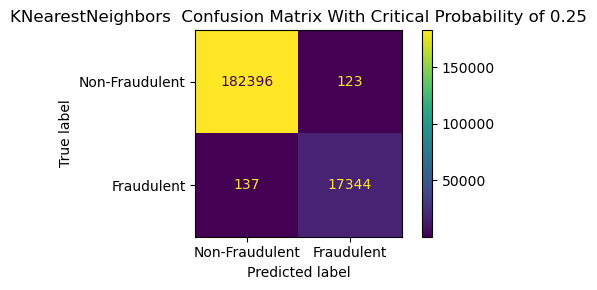

Accuracy: 0.9986500000609334
Test Accuracy Score: 0.9987
{'kneighborsclassifier__n_neighbors': 1}


In [2]:
## K NEAREST NEIGHBORS


data = pd.read_csv('data/card_transdata.csv')
#feature matrix and target variable

X=data.loc[:,data.columns != 'fraud']
y=data['fraud']
##feature matrix and target variable

# subset_size = 15000
# subset_df = data.sample(n=subset_size, random_state=42, replace=False) 

# X=subset_df.loc[:,subset_df.columns != 'fraud']
# y=subset_df['fraud']



def ML_Pipeline_Kfold(X, y,random_state, n_folds):

    X_other, X_test, y_other, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state = random_state)
    #
    #X_val, X_test, y_val, y_test = train_test_split(X_other,y_other,train_size = 0.5,stratify=y_other,random_state=random_state)
    # splitter for _other
    
    kf = StratifiedKFold(n_splits=3,shuffle=True,random_state=random_state)


    cat_ftrs = ['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']
    std_ftrs = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']

    preprocessor = ColumnTransformer(
       transformers=[
        ('onehot', OneHotEncoder(sparse_output=False, handle_unknown= 'ignore'), cat_ftrs),
        ('std', StandardScaler(), std_ftrs)])
    
    clf = KNeighborsClassifier()
    pipe = make_pipeline(preprocessor, clf)
    #set parameters
    param_grid = [
    {
        'kneighborsclassifier__n_neighbors': [1, 3, 5, 10]
    }
    ]

    grid = GridSearchCV(pipe, param_grid=param_grid,cv=kf, return_train_score = True,n_jobs=6,verbose=True)
    # do kfold CV on _other
    grid.fit(X_other, y_other)
        # Fit the model on the other set

    # Extract the best estimator from the grid search
    best_model = grid.best_estimator_

    # Predict on the test set
    y_pred = best_model.predict(X_test)
    
    results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

    
    # Save the DataFrame to a CSV file
    results_df.to_csv('knn_results.csv', index=False)


    # Print or use the DataFrame as needed
    print(results_df)

    #Generate Confusion Matrix
    critical_probability = 0.25
    y_probs = best_model.predict_proba(X_test)[:, 1]
    y_pred_adjusted = np.where(y_probs >= critical_probability, 1, 0)
    cm = confusion_matrix(y_test, y_pred_adjusted)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Fraudulent', 'Fraudulent'])
    fig, ax = plt.subplots(figsize=(5, 3))
    disp.plot(ax=ax)
    plt.title('KNearestNeighbors  Confusion Matrix With Critical Probability of 0.25')
    plt.tight_layout()
    plt.savefig('KNN_cm.png', dpi = 300, bbox_inches='tight')
    plt.show()
   


    #generate scatterplot of y true versus y pred 

    return grid, X_test, y_test, cm



#interpretation
model, X_test, y_test, cm = ML_Pipeline_Kfold(X,y,42,4)
print("Accuracy:", model.best_score_) 
print("Test Accuracy Score:", model.score(X_test,y_test)) 
print(model.best_params_)

Fitting 3 folds for each of 14 candidates, totalling 42 fits
        Actual  Predicted
263245     0.0        0.0
961975     0.0        0.0
275346     0.0        0.0
998436     1.0        1.0
489168     1.0        1.0
...        ...        ...
482053     0.0        0.0
899599     0.0        0.0
131979     0.0        0.0
728199     0.0        0.0
391133     0.0        0.0

[3000 rows x 2 columns]


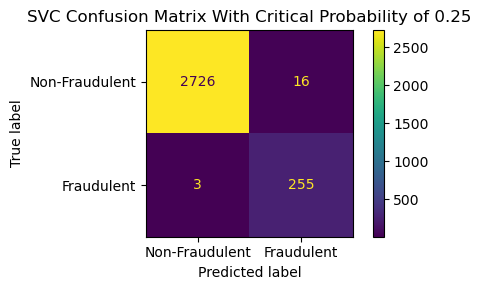

Accuracy: 0.99375
Test Accuracy Score: 0.9976666666666667
{'svc__C': 100.0, 'svc__gamma': 'scale'}


In [3]:
#SVC




data = pd.read_csv('data/card_transdata.csv')
#feature matrix and target variable

# X=data.loc[:,data.columns != 'fraud']
# y=data['fraud']
##feature matrix and target variable

subset_size = 15000
subset_df = data.sample(n=subset_size, random_state=42, replace=False) 

X=subset_df.loc[:,subset_df.columns != 'fraud']
y=subset_df['fraud']



def ML_Pipeline_Kfold(X, y,random_state, n_folds):

    X_other, X_test, y_other, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state = random_state)
    #
    #X_val, X_test, y_val, y_test = train_test_split(X_other,y_other,train_size = 0.5,stratify=y_other,random_state=random_state)
    # splitter for _other
    
    kf = StratifiedKFold(n_splits=3,shuffle=True,random_state=random_state)


    cat_ftrs = ['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']
    std_ftrs = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']

    preprocessor = ColumnTransformer(
       transformers=[
        ('onehot', OneHotEncoder(sparse_output=False, handle_unknown= 'ignore'), cat_ftrs),
        ('std', StandardScaler(), std_ftrs)])
    
    clf = SVC(probability=True)
    pipe = make_pipeline(preprocessor, clf)
    #set parameters
    param_grid = [
    {
            'svc__C': np.logspace(-3, 3, 7),
            'svc__gamma': ['scale', 'auto']}
    ]

    grid = GridSearchCV(pipe, param_grid=param_grid,cv=kf, return_train_score = True,n_jobs=6,verbose=True)
    # do kfold CV on _other
    grid.fit(X_other, y_other)
        # Fit the model on the other set

    # Extract the best estimator from the grid search
    best_model = grid.best_estimator_

    # Predict on the test set
    y_pred = best_model.predict(X_test)

    results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

    
    # Save the DataFrame to a CSV file
    results_df.to_csv('svc_results.csv', index=False)


    # Print or use the DataFrame as needed
    print(results_df)
    
    
    #Generate Confusion Matrix
    critical_probability = 0.25
    y_probs = best_model.predict_proba(X_test)[:, 1]
    y_pred_adjusted = np.where(y_probs >= critical_probability, 1, 0)
    cm = confusion_matrix(y_test, y_pred_adjusted)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Fraudulent', 'Fraudulent'])
    fig, ax = plt.subplots(figsize=(5, 3))
    disp.plot(ax=ax)
    plt.title('SVC Confusion Matrix With Critical Probability of 0.25')
    plt.tight_layout()
    plt.savefig('svc_cm.png', dpi = 300, bbox_inches='tight')
    plt.show()
   


    #generate scatterplot of y true versus y pred 

    return grid, X_test, y_test, cm



#interpretation
model, X_test, y_test, cm = ML_Pipeline_Kfold(X,y,42,4)
print("Accuracy:", model.best_score_) 
print("Test Accuracy Score:", model.score(X_test,y_test)) 
print(model.best_params_)

### 